# Colorectal Cancer Tissue Classification
## Deep Learning Final Project - 2025–2026


## Setup & Imports

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms, models
import medmnist
from medmnist import PathMNIST, INFO
from sklearn.metrics import confusion_matrix, classification_report, f1_score
import warnings, time, copy
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")
# cuda means GPU

Using device: cuda


---
## Part 1: Data Exploration
We load PathMNIST, examine its structure, visualise sample images, and characterise the class distribution and pixel statistics before building any model.


In [ ]:
# Loading dataset
info = INFO['pathmnist']
# give informations about the dataset
print("Dataset info:")
print(f"  Task: {info['task']}")
print(f"  N classes: {info['n_channels']} channels, {len(info['label'])} classes")
# channels : 3 (RGB)
# classes : 9 different tissue types
print(f"  Labels: {info['label']}")

CLASSES = list(info['label'].values())
print(f"\nClass names: {CLASSES}")
# get the tissue name into a list for later use

# Raw (no normalisation) for pixel statistics
raw_transform = transforms.Compose([transforms.ToTensor()])
# rescale values and convert to tensor
# no normalisation yet, we want to see the original pixel value distribution
# tensor : multi-dimensional array used in PyTorch for storing data and gradients
# change from PIL image (H×W×C, uint8 in [0,255]) to tensor (C×H×W, float32 in [0,1])

train_raw = PathMNIST(split='train', transform=raw_transform, download=True)
val_raw   = PathMNIST(split='val',   transform=raw_transform, download=True)
test_raw  = PathMNIST(split='test',  transform=raw_transform, download=True)
# download and load the dataset
# 3 different splits : train, validation, test

print(f"\nSplit sizes = train: {len(train_raw):,}, val: {len(val_raw):,}, test: {len(test_raw):,}")
print(f"Image shape = {train_raw[0][0].shape} ")


Dataset info:
  Task: multi-class
  N classes: 3 channels, 9 classes
  Labels: {'0': 'adipose', '1': 'background', '2': 'debris', '3': 'lymphocytes', '4': 'mucus', '5': 'smooth muscle', '6': 'normal colon mucosa', '7': 'cancer-associated stroma', '8': 'colorectal adenocarcinoma epithelium'}

Class names: ['adipose', 'background', 'debris', 'lymphocytes', 'mucus', 'smooth muscle', 'normal colon mucosa', 'cancer-associated stroma', 'colorectal adenocarcinoma epithelium']

Split sizes = train: 89,996, val: 10,004, test: 7,180
Image shape = torch.Size([3, 28, 28]) 


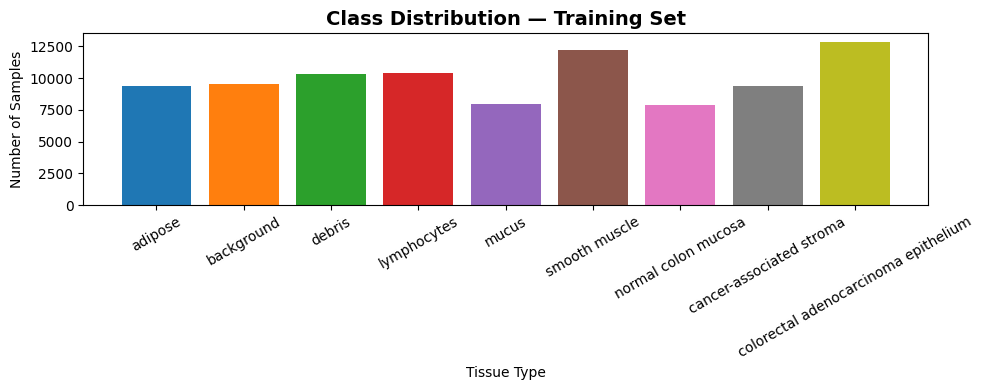


Counts per class:
   0  adipose                9,366
   1  background             9,509
   2  debris                10,360
   3  lymphocytes           10,401
   4  mucus                  8,006
   5  smooth muscle         12,182
   6  normal colon mucosa    7,886
   7  cancer-associated stroma   9,401
   8  colorectal adenocarcinoma epithelium  12,885


In [ ]:
# Class distribution
all_labels = np.array([int(train_raw[i][1]) for i in range(len(train_raw))])
# loop every image in the training and extract the label
# tuple (image, label) so 1 is the label
unique, counts = np.unique(all_labels, return_counts=True)
# count how many time each value appears

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar([CLASSES[u] for u in unique], counts, color=sns.color_palette("tab10", 9))
ax.set_title("Class Distribution — Training Set", fontsize=14, fontweight='bold')
ax.set_xlabel("Tissue Type")
ax.set_ylabel("Number of Samples")
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()
print("\nCounts per class:")
for u, c in zip(unique, counts):
    print(f"  {u:2d}  {CLASSES[u]:<20s}  {c:6,}")


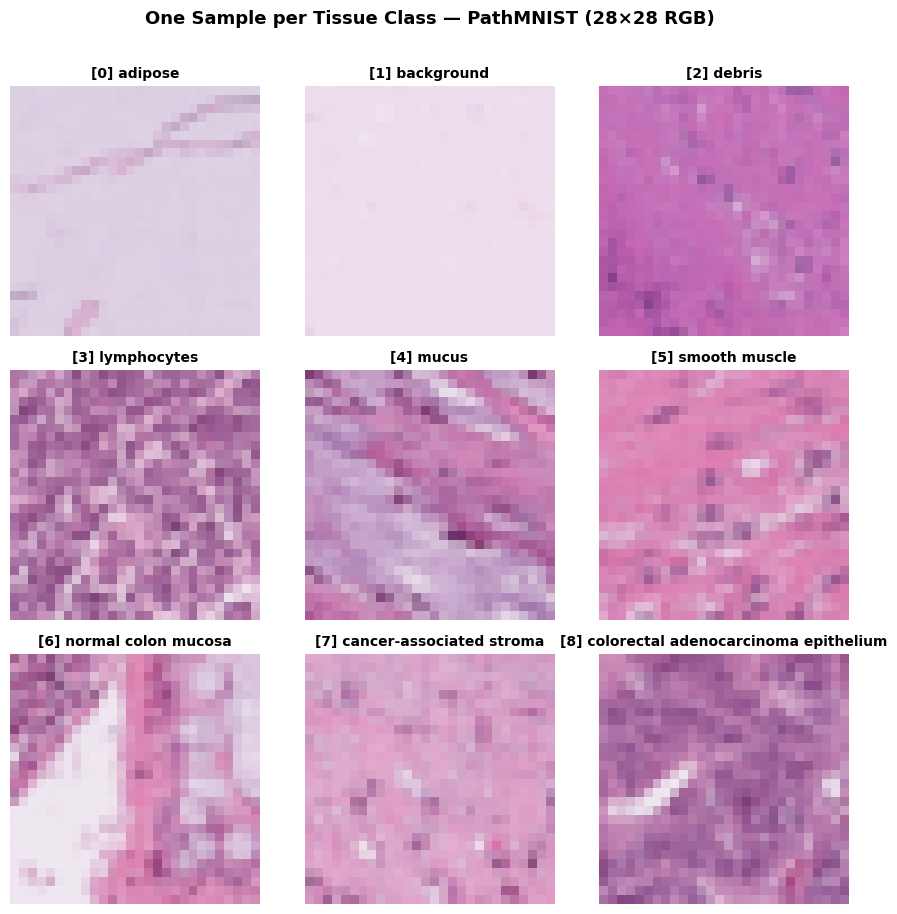

In [ ]:
# Data exploration: visualisation of the figures
fig, axes = plt.subplots(3, 3, figsize=(9, 9))
axes = axes.flatten()

# Collect one representative image per class
class_examples = {}
for img, label in train_raw:
    lbl = int(label)
    if lbl not in class_examples:
        class_examples[lbl] = img
    if len(class_examples) == 9:
        break
# Loop through the dataset
# Save the first image found for each class

for image_exploration in range(9):
    img = class_examples[image_exploration].permute(1, 2, 0).numpy()
    # PyTorch stores images as [C, H, W] but matplotlib expects [H, W, C]
    axes[image_exploration].imshow(img)
    axes[image_exploration].set_title(f"[{image_exploration}] {CLASSES[image_exploration]}", fontsize=10, fontweight='bold')
    axes[image_exploration].axis('off')
    # No x y axis and numbers

plt.suptitle("One Sample per Tissue Class — PathMNIST (28×28 RGB)", fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


You need to check the particularities of each image and what are the differences between the different categories

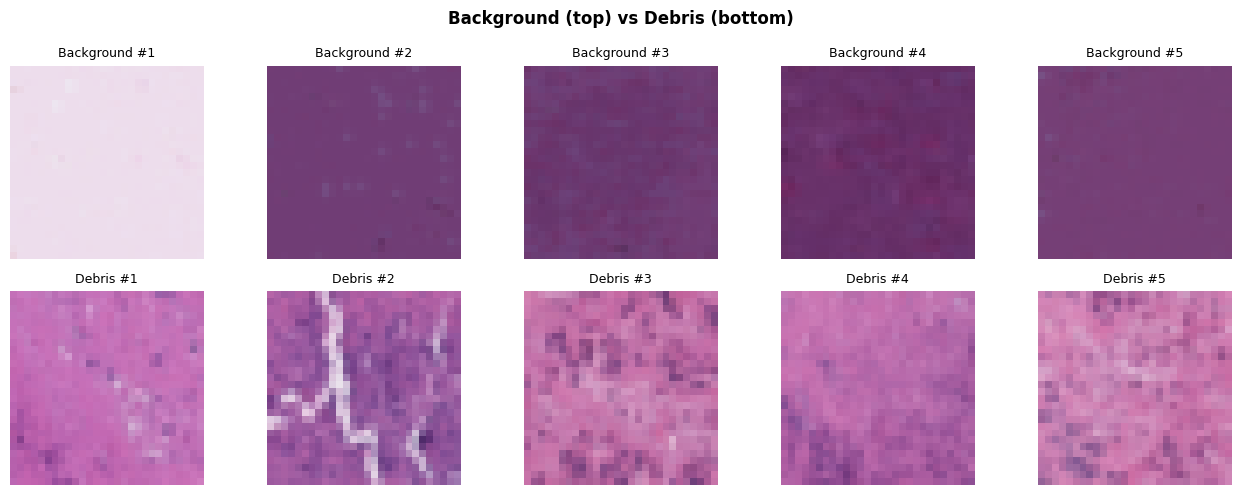

In [ ]:
# Data exploration: debris vs background
# Collect 5 examples each of Background (1) and Debris (2)
debris_imgs, bg_imgs = [], []
for img, label in train_raw:
    lbl = int(label)
    if lbl == 2 and len(debris_imgs) < 5:
        debris_imgs.append(img)
    if lbl == 1 and len(bg_imgs) < 5:
        bg_imgs.append(img)
    if len(debris_imgs) == 5 and len(bg_imgs) == 5:
        break

fig, axes = plt.subplots(2, 5, figsize=(13, 5))
for i in range(5):
    axes[0, i].imshow(bg_imgs[i].permute(1,2,0).numpy())
    axes[0, i].set_title(f"Background #{i+1}", fontsize=9)
    axes[0, i].axis('off')
    axes[1, i].imshow(debris_imgs[i].permute(1,2,0).numpy())
    axes[1, i].set_title(f"Debris #{i+1}", fontsize=9)
    axes[1, i].axis('off')

plt.suptitle("Background (top) vs Debris (bottom)", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


### Q1.1 Debris vs Background

**Background** images are characterised by a nearly uniform, very light pinkish-white (almost white) field with no visible cellular structure.  The texture is essentially flat, a natural consequence of empty slide areas that contain no tissue

**Debris** images, by contrast, show heterogeneous, granular material: irregular dark fragments or clumps scattered against a lighter background.  The texture is noticeably noisier, with localised dark spots or streaks that give the image a "dusty" or "fragmented" appearance.

**Specific colour/texture observation:** Background patches have a very pale, nearly monochromatic pink hue, making them look almost white.  Debris patches have a much wider colour range: dark purple or brown fragments (low R, even lower B) sit against the same pale background.  

The standard deviation of pixel intensities is substantially higher in Debris than in Background, and the minimum pixel value is much lower.


Chosen image label: 5 — smooth muscle
Tensor shape: torch.Size([3, 28, 28])

  Channel R:  mean = 0.826726   std = 0.054718
  Channel G:  mean = 0.530762   std = 0.068269
  Channel B:  mean = 0.712770   std = 0.046520

ImageNet normalisation statistics (reference):
  Channel R:  ImageNet mean=0.485  (diff 0.342)  ImageNet std=0.229  (diff 0.174)
  Channel G:  ImageNet mean=0.456  (diff 0.075)  ImageNet std=0.224  (diff 0.156)
  Channel B:  ImageNet mean=0.406  (diff 0.307)  ImageNet std=0.225  (diff 0.178)


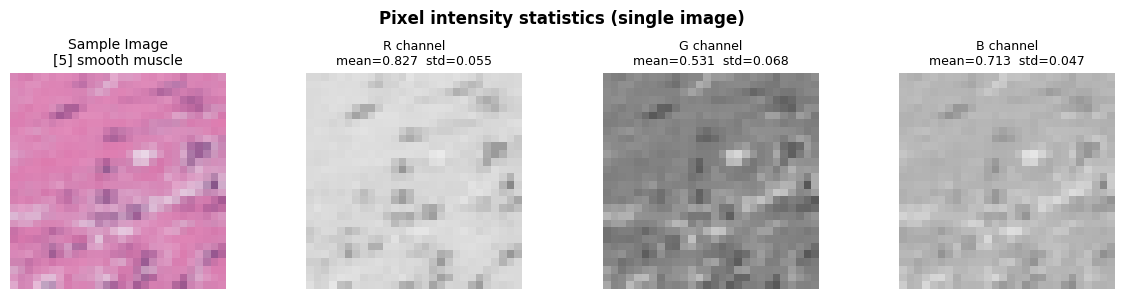

In [ ]:
# Pixel intensity statistics for one training image ─
sample_img, sample_label = train_raw[3]
# tensor shape [3, 28, 28], values in range [0,1]

print(f"Chosen image label: {int(sample_label)} — {CLASSES[int(sample_label)]}")
print(f"Tensor shape: {sample_img.shape}")
print()

channel_names = ['R', 'G', 'B']
means, stds = [], []
for c, name in enumerate(channel_names):
    ch = sample_img[c]
    m = ch.mean().item()
    s = ch.std().item()
    means.append(m)
    stds.append(s)
    print(f"  Channel {name}:  mean = {m:.6f}   std = {s:.6f}")
# sample img extract 1 channel at a time
# 3 channels
# measure the mean and std for each channel and save in list
# item convert the result to a python float to print it
print()
print("ImageNet normalisation statistics (reference):")
# Check the imagenet dataset and mean and std for each channel
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std  = [0.229, 0.224, 0.225]
for c, name in enumerate(channel_names):
    diff_m = abs(means[c] - imagenet_mean[c])
    diff_s = abs(stds[c] - imagenet_std[c])
    print(f"  Channel {name}:  ImageNet mean={imagenet_mean[c]:.3f}  (diff {diff_m:.3f})  "
          f"ImageNet std={imagenet_std[c]:.3f}  (diff {diff_s:.3f})")

# Visualise the chosen images
fig, axes = plt.subplots(1, 4, figsize=(12, 3))
axes[0].imshow(sample_img.permute(1,2,0).numpy())
axes[0].set_title(f"Sample Image\n[{int(sample_label)}] {CLASSES[int(sample_label)]}", fontsize=10)
axes[0].axis('off')
for c, (name, color) in enumerate(zip(channel_names, ['red','green','blue'])):
    axes[c+1].imshow(sample_img[c].numpy(), cmap='gray', vmin=0, vmax=1)
    axes[c+1].set_title(f"{name} channel\nmean={means[c]:.3f}  std={stds[c]:.3f}", fontsize=9)
    axes[c+1].axis('off')
plt.suptitle("Pixel intensity statistics (single image)", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


### Q1.2 Pixel Statistics vs ImageNet

As can be seen with the precedent result, histopathology images (HE staining) differ from natural photographs:

**Mean values** are higher (closer to 1.0) because large portions of the slide are bright pink (eosin staining, extracellular matrix and cell cytoplasm) or near-white (unstained areas), pushing overall brightness up.

**Standard deviations** in histology images are typically lower than ImageNet ones because tissue patches have narrower chromatic range (predominantly pink/purple palette, because the staining is in this palette range). There is some deeper contrasts with the hematoxylin staining, but as it stains only nuclei, there is less contrast than in an usual picture

**Practical implication:** In the the part 4, we should still apply ImageNet normalisation (subtract ImageNet mean, divide by ImageNet std) because the pretrained feature detectors were calibrated for that distribution.  However, the mismatch between PathMNIST statistics and ImageNet ones may slightly impairs feature reuse, especially in the first conv layer


In [ ]:
# Dataset-wide statistics (for normalisation)
# Compute mean and std across all training images
loader_stats = DataLoader(train_raw, batch_size=512, shuffle=False, num_workers=2)
# too complicated to load all the images into memory
# process in batches of 512
# don't care about shuffle
channel_sum = torch.zeros(3)
channel_sq_sum = torch.zeros(3)
n_pixels = 0
# three counters for each channel : sum of pixel values, sum of squared pixel values, total number of pixels

for imgs, _ in loader_stats:
    # imgs: [512, 3, 28, 28]
    channel_sum    += imgs.sum(dim=[0, 2, 3])
    # Keep channel dimensions and sum over batch, height, width
    channel_sq_sum += (imgs ** 2).sum(dim=[0, 2, 3])
    # same but for squared pixel values
    n_pixels       += imgs.shape[0] * 28 * 28
    # count the number of pixels in the batch and add to total

dataset_mean = channel_sum / n_pixels
dataset_std  = ((channel_sq_sum / n_pixels) - dataset_mean**2).sqrt()

print("PathMNIST training-set statistics:")
for c, name in enumerate(channel_names):
    print(f"  Channel {name}:  mean = {dataset_mean[c]:.4f}   std = {dataset_std[c]:.4f}")
print()
print("We will use these values for normalising inputs to the MLP and CNN.")
print("For ResNet-18 we use ImageNet statistics instead.")


PathMNIST training-set statistics:
  Channel R:  mean = 0.7405   std = 0.1237
  Channel G:  mean = 0.5330   std = 0.1768
  Channel B:  mean = 0.7058   std = 0.1244

We will use these values for normalising inputs to the MLP and CNN.
For ResNet-18 we use ImageNet statistics instead.


## Dense Network Baseline (MLP)
We build a multi-layer with

≥2 hidden layers and dropout to establish a baseline

The goal is ≥55 % test accuracy.


In [ ]:
# Normalised datasets & loaders
mlp_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=dataset_mean.tolist(),
                         std=dataset_std.tolist()),
])
# _mlp is a completely new dataset object
# it doesn't inherit anything from _raw

train_mlp = PathMNIST(split='train', transform=mlp_transform, download=True)
val_mlp   = PathMNIST(split='val',   transform=mlp_transform, download=True)
test_mlp  = PathMNIST(split='test',  transform=mlp_transform, download=True)
# reload dataset with the new transform that includes normalisation

BATCH_SIZE = 256
# same, we load only in batches to avoid memory issues
train_loader = DataLoader(train_mlp, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_mlp,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_mlp,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
# we need to shuffle for the training so it doesn't learn the order
# 2 CPU threads to load the data
# pin_memory=true for faster transfer to GPU

print(f"Batch size : {BATCH_SIZE}")
print(f"Train batches: {len(train_loader)} Val batches: {len(val_loader)} Test batches: {len(test_loader)}")


Batch size : 256
Train batches: 352 Val batches: 40 Test batches: 29


In [ ]:
# MLP architecture
class MLP(nn.Module):
    """
    Multi-Layer Perceptron for 28×28 RGB images : 9 classes.

    Architecture (chosen after brief ablation):
      Input  : 28×28×3 = 2352 features (flattened)
      Layer 1: Linear(2352 -> 1024) + BatchNorm + ReLU + Dropout(0.4)
      Layer 2: Linear(1024 -> 512)  + BatchNorm + ReLU + Dropout(0.4)
      Layer 3: Linear(512  -> 256)  + BatchNorm + ReLU + Dropout(0.3)
      Output : Linear(256  -> 9)

    Design rationale

    - Three hidden layers give a good depth-vs-overfitting trade-off on this dataset.
    - BatchNorm before ReLU stabilises training and reduces sensitivity to lr.
    - Dropout rates decrease towards the head because earlier layers are wider
     and more prone to co-adaptation.
    - No activation on the output layer: we use nn.CrossEntropyLoss which expects
     raw logits (it applies log-softmax internally).
    """
    def __init__(self, input_dim=3*28*28, hidden=[1024, 512, 256], n_classes=9,
                 dropout=[0.4, 0.4, 0.3]):
        super().__init__()
        layers = []
        in_features = input_dim
        for i, (h, d) in enumerate(zip(hidden, dropout)):
            layers += [
                nn.Linear(in_features, h),
                nn.BatchNorm1d(h),
                nn.ReLU(inplace=True),
                nn.Dropout(d),
            ]
            in_features = h
        layers.append(nn.Linear(in_features, n_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        x = x.view(x.size(0), -1)   # flatten
        return self.net(x)

mlp = MLP().to(DEVICE)
total_params = sum(p.numel() for p in mlp.parameters() if p.requires_grad)
print(f"MLP total trainable parameters: {total_params:,}")
print(mlp)


MLP total trainable parameters: 3,071,497
MLP(
  (net): Sequential(
    (0): Linear(in_features=2352, out_features=1024, bias=True)
    (1): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=1024, out_features=512, bias=True)
    (5): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): Dropout(p=0.4, inplace=False)
    (8): Linear(in_features=512, out_features=256, bias=True)
    (9): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=256, out_features=9, bias=True)
  )
)


In [ ]:
# 2.2  Training utilities
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.squeeze(1).long().to(device)
        # go to gpu if available
        # delete the extra dimension in label
        # convert to integer for loss calculation
        optimizer.zero_grad()
        # clear gradients before backpropagation
        # reset at each iteration
        logits = model(imgs)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        # accumulate loss weighted by batch size
        preds = logits.argmax(1)
        correct += (preds == labels).sum().item()
        # count how many predictions are correct
        total   += imgs.size(0)
    return total_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
    # no need to compute gradients
    # will save memory
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.squeeze(1).long().to(device)
            logits = model(imgs)
            loss = criterion(logits, labels)
            total_loss += loss.item() * imgs.size(0)
            preds = logits.argmax(1)
            correct += (preds == labels).sum().item()
            total   += imgs.size(0)
    return total_loss / total, correct / total


def get_all_preds(model, loader, device):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            preds = model(imgs).argmax(1).cpu().numpy()
            # move back to cpu
            all_preds.extend(preds)
            all_labels.extend(labels.squeeze(1).numpy())
             # for sklearn confusion matrix
    return np.array(all_preds), np.array(all_labels)


In [ ]:
# Train MLP
MLP_EPOCHS = 40
MLP_LR     = 1e-3
# learning rate
MLP_WD     = 1e-4
# weight decay

criterion = nn.CrossEntropyLoss()
# mesure the difference between predicted logits and true labels
optimizer = optim.Adam(mlp.parameters(), lr=MLP_LR, weight_decay=MLP_WD)
# update the weights of the model based on the computed loss
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=MLP_EPOCHS)
# adjust the learning rate during training using a cosine annealing schedule

mlp_train_loss, mlp_val_loss   = [], []
mlp_train_acc,  mlp_val_acc    = [], []

# Values we must report precisely for Q2.1
checkpoints = {1: None, 10: None}

print(f"{'Epoch':>5}  {'Train Loss':>10}  {'Train Acc':>9}  {'Val Loss':>9}  {'Val Acc':>8}")
print("-" * 55)

for epoch in range(1, MLP_EPOCHS + 1):
    t_loss, t_acc = train_one_epoch(mlp, train_loader, criterion, optimizer, DEVICE)
    v_loss, v_acc = evaluate(mlp, val_loader, criterion, DEVICE)
    scheduler.step()

    mlp_train_loss.append(t_loss)
    mlp_val_loss.append(v_loss)
    mlp_train_acc.append(t_acc)
    mlp_val_acc.append(v_acc)

    if epoch in checkpoints:
        checkpoints[epoch] = {'val_loss': v_loss, 'val_acc': v_acc,
                              'train_acc': t_acc, 'train_loss': t_loss}

    if epoch % 5 == 0 or epoch == 1:
        print(f"{epoch:>5}  {t_loss:>10.6f}  {t_acc*100:>8.4f}%  {v_loss:>9.6f}  {v_acc*100:>7.4f}%")

# Final epoch
checkpoints['final'] = {'val_loss': mlp_val_loss[-1], 'val_acc': mlp_val_acc[-1],
                        'train_acc': mlp_train_acc[-1], 'train_loss': mlp_train_loss[-1],
                        'epoch': MLP_EPOCHS}
print(f"\n{'='*55}")
print("Q2.1 REPORT  (exact values, not rounded):")
for key in [1, 10, 'final']:
    ep = key if key != 'final' else checkpoints['final']['epoch']
    d  = checkpoints[key]
    print(f"  Epoch {ep:>2d}:  val_loss = {d['val_loss']:.8f}   train_acc = {d['train_acc']*100:.6f}%   val_acc = {d['val_acc']*100:.6f}%")


Epoch  Train Loss  Train Acc   Val Loss   Val Acc
-------------------------------------------------------
    1    1.047156   60.0793%   0.868033  67.5330%
    5    0.807150   68.6419%   0.761971  71.0116%
   10    0.734370   71.9210%   0.753834  71.2615%
   15    0.668096   74.5755%   0.692582  74.0804%
   20    0.593674   77.5534%   0.674577  74.7901%
   25    0.503973   81.2192%   0.663790  75.8896%
   30    0.412507   84.5882%   0.679141  76.0796%
   35    0.355272   86.8227%   0.700427  76.2395%
   40    0.331415   87.7672%   0.698904  76.6693%

Q2.1 REPORT  (exact values, not rounded):
  Epoch  1:  val_loss = 0.86803300   train_acc = 60.079337%   val_acc = 67.532987%
  Epoch 10:  val_loss = 0.75383448   train_acc = 71.920974%   val_acc = 71.261495%
  Epoch 40:  val_loss = 0.69890428   train_acc = 87.767234%   val_acc = 76.669332%


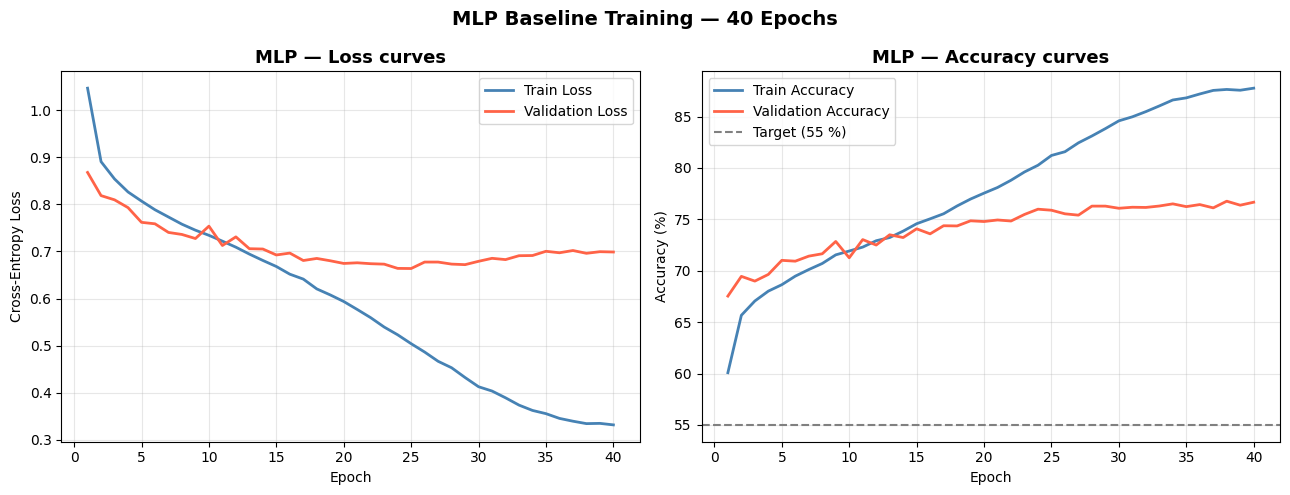

In [ ]:
# 2.4  Training curves
epochs = range(1, MLP_EPOCHS + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.plot(epochs, mlp_train_loss, label='Train Loss',      linewidth=2, color='steelblue')
ax1.plot(epochs, mlp_val_loss,   label='Validation Loss', linewidth=2, color='tomato')
ax1.set_title("MLP — Loss curves", fontsize=13, fontweight='bold')
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Cross-Entropy Loss")
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(epochs, [a*100 for a in mlp_train_acc], label='Train Accuracy',      linewidth=2, color='steelblue')
ax2.plot(epochs, [a*100 for a in mlp_val_acc],   label='Validation Accuracy', linewidth=2, color='tomato')
ax2.axhline(55, color='grey', linestyle='--', label='Target (55 %)')
ax2.set_title("MLP — Accuracy curves", fontsize=13, fontweight='bold')
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy (%)")
ax2.legend()
ax2.grid(alpha=0.3)

plt.suptitle(f"MLP Baseline Training — {MLP_EPOCHS} Epochs", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('mlp_curves.png', dpi=120, bbox_inches='tight')
plt.show()


# A gauche :
Les deux courbes descendent bien au début : apprentissage
-15 : OVERFITTING

# A droite :
Ecart entre train et val qui confirme l'overfitting !!!

MLP Test Accuracy : 64.9721%  (target ≥ 55 %)
MLP Test Loss     : 1.421897


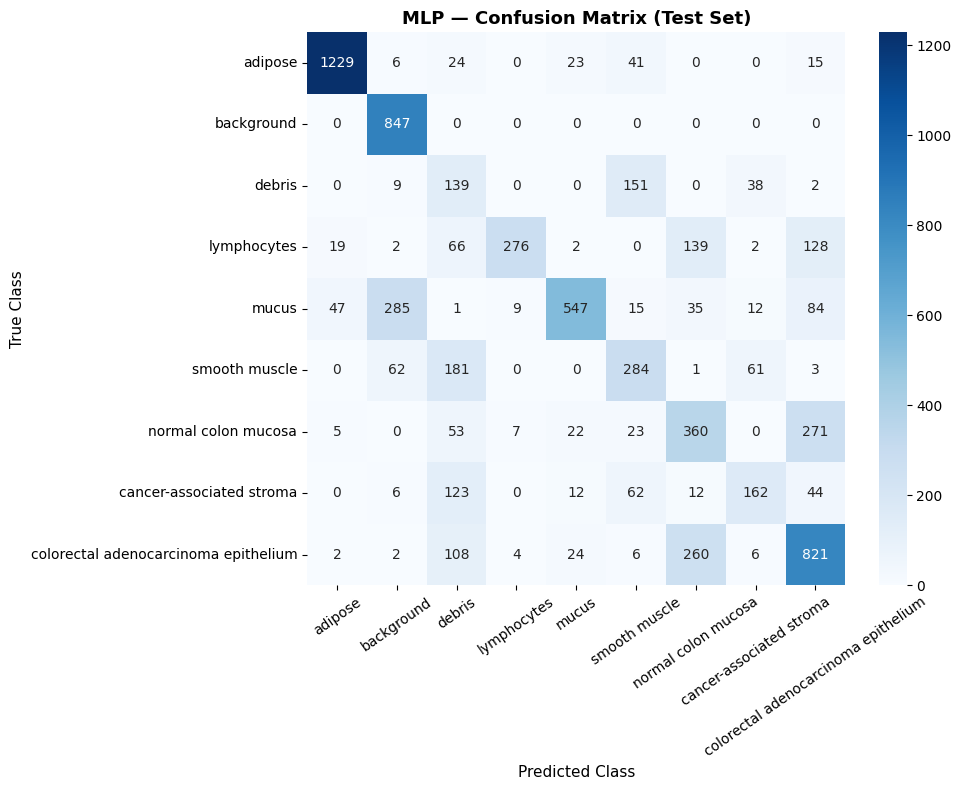


Q2.2 : Worst misclassification:
  True class      : 4 (mucus)
  Predicted class : 1 (background)
  Count           : 285


In [ ]:
# 2.5  Test accuracy & confusion matrix (final evaluation)
test_loss, test_acc = evaluate(mlp, test_loader, criterion, DEVICE)
print(f"MLP Test Accuracy : {test_acc*100:.4f}%  (target ≥ 55 %)")
print(f"MLP Test Loss     : {test_loss:.6f}")

preds_mlp, labels_mlp = get_all_preds(mlp, test_loader, DEVICE)
cm_mlp = confusion_matrix(labels_mlp, preds_mlp)
# confusion matrix

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm_mlp, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES, ax=ax)
ax.set_title("MLP — Confusion Matrix (Test Set)", fontsize=13, fontweight='bold')
ax.set_xlabel("Predicted Class", fontsize=11)
ax.set_ylabel("True Class", fontsize=11)
ax.tick_params(axis='x', rotation=35)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.savefig('mlp_confusion.png', dpi=120, bbox_inches='tight')
plt.show()

# Q2.2 : find the single worst off-diagonal cell
cm_offdiag = cm_mlp.copy()
# copy to not modify the original confusion matrix
np.fill_diagonal(cm_offdiag, 0)
# set the diagonal to zero so we only look at misclassifications
max_idx = np.unravel_index(cm_offdiag.argmax(), cm_offdiag.shape)
# find the maximal value in the matrix
# find the linear index of the maximum value and convert to 2D index
pred_cls, true_cls = max_idx[1], max_idx[0]
print(f"\nQ2.2 : Worst misclassification:")
print(f"  True class      : {true_cls} ({CLASSES[true_cls]})")
print(f"  Predicted class : {pred_cls} ({CLASSES[pred_cls]})")
print(f"  Count           : {cm_offdiag[max_idx]}")


### Q2.1: Exact Validation Loss and Accuracy

Q2.1 REPORT  (exact values, not rounded):

  Epoch  1:  val_loss = 0.86803300   train_acc = 60.079337%   val_acc = 67.532987%

  Epoch 10:  val_loss = 0.75383448   train_acc = 71.920974%   val_acc = 71.261495%
  
  Epoch 40:  val_loss = 0.69890428   train_acc = 87.767234%   val_acc = 76.669332%


### Q2.2: Worst Misclassification

The worst one is debris vs smooth muscle. With a 28 x 28 pixel, the debris and the smooth muscle have granulosity.
However, the most important and clinical relevant mistake is the normal colon mucosa vs Colorectal adenocarcinoma.
This is a MLP issue : we flatten the pixel and loose the spatial informations of the tissues


---
## Part 4: Transfer Learning with ResNet-18
We fine-tune an ImageNet-pretrained ResNet-18 on PathMNIST.
ResNet18 : already trained on ImageNet
- **(a) .Frozen backbone**
Freeze layers so their weight doesn't move during the training. We train only the last layer. Very fast
- **(b) Full fine-tuning**
We train the entire network. Slow

In [ ]:
# Data loaders (ImageNet normalisation + resize to 224)
# Different from part 2
# We need to use the ImageNet normalisation for ResNet-18 because it was pretrained on ImageNet and expects inputs to be normalised in the same way
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std  = [0.229, 0.224, 0.225]

resnet_transform_train = transforms.Compose([
    transforms.Resize(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])
# Random flip
# Artificially increase the size of the dataset by applying random horizontal and vertical flips to the training images
# This helps the model generalise better by learning from different orientations of the same image

resnet_transform_eval = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])
# ResNet-18 was trained on 224×224 images, so we need to resize our 28×28 images to 224×224
# Upscaling from 28 to 224

train_rn = PathMNIST(split='train', transform=resnet_transform_train, download=True)
val_rn   = PathMNIST(split='val',   transform=resnet_transform_eval,  download=True)
test_rn  = PathMNIST(split='test',  transform=resnet_transform_eval,  download=True)

BS_RN = 128
# Reduce the batch size to save memory
rn_train_loader = DataLoader(train_rn, batch_size=BS_RN, shuffle=True,  num_workers=2, pin_memory=True)
rn_val_loader   = DataLoader(val_rn,   batch_size=BS_RN, shuffle=False, num_workers=2, pin_memory=True)
rn_test_loader  = DataLoader(test_rn,  batch_size=BS_RN, shuffle=False, num_workers=2, pin_memory=True)

print(f"Input image size after resize: 224×224")
print(f"Train batches: {len(rn_train_loader)}, Val: {len(rn_val_loader)}, Test: {len(rn_test_loader)}")


Input image size after resize: 224×224
Train batches: 704, Val: 79, Test: 57


In [ ]:
# Build ResNet-18 (helper)
def build_resnet18(freeze_backbone: bool, n_classes: int = 9):
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    # Load the ResNet-18 architecture with pretrained weights on ImageNet

    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False
    # Don't compute gradients for the backbone if we are freezing it

    # Replace classification head (always trainable)
    in_features = model.fc.in_features
    # 512
    model.fc = nn.Linear(in_features, n_classes)
    # new head, requires_grad=True by default

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in model.parameters())
    mode = "FROZEN backbone" if freeze_backbone else "FULL fine-tuning"
    print(f"ResNet-18 ({mode}): trainable {trainable:,}, {total:,} parameters")
    return model


In [ ]:
# Training loop for ResNet
def train_resnet(model, train_loader, val_loader, n_epochs, lr, weight_decay, device,
                 label='ResNet'):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                            lr=lr, weight_decay=weight_decay)
    # We use AdamW which decouples weight decay from the gradient update, which is often better for training transformers and large models
    # Only pass the parameters that require gradients to the optimizer (important when freezing the backbone)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs)

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    # For plotting
    best_val_acc = 0.0
    best_state   = None

    print(f"{'Epoch':>5}  {'Train Loss':>10}  {'Train Acc':>9}  {'Val Loss':>9}  {'Val Acc':>8}")

    for epoch in range(1, n_epochs + 1):
        t_loss, t_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        v_loss, v_acc = evaluate(model, val_loader, criterion, device)
        scheduler.step()

        history['train_loss'].append(t_loss)
        history['val_loss'].append(v_loss)
        history['train_acc'].append(t_acc)
        history['val_acc'].append(v_acc)

        if v_acc > best_val_acc:
            best_val_acc = v_acc
            best_state   = copy.deepcopy(model.state_dict())
        # Save the best model state based on validation accuracy

        if epoch % 3 == 0 or epoch == 1:
            print(f"{epoch:>5}  {t_loss:>10.6f}  {t_acc*100:>8.4f}%  {v_loss:>9.6f}  {v_acc*100:>7.4f}%")

    model.load_state_dict(best_state)
    # Restore best checkpoint to avoid overfitting in later epochs
    print(f"\nBest val accuracy ({label}): {best_val_acc*100:.4f}%")
    return model, history


In [ ]:
# Experiment (a): Frozen backbone
RN_EPOCHS   = 20
RN_LR_FROZEN = 1e-3
RN_LR_FULL   = 1e-4
# smaller lr for full fine-tuning (pretrained weights are fragile)
RN_WD        = 1e-4

print("EXPERIMENT (a): Frozen backbone — only head trained")
resnet_frozen = build_resnet18(freeze_backbone=True).to(DEVICE)
# Move back to GPU if available
resnet_frozen, hist_frozen = train_resnet(
    resnet_frozen, rn_train_loader, rn_val_loader,
    n_epochs=RN_EPOCHS, lr=RN_LR_FROZEN, weight_decay=RN_WD,
    device=DEVICE, label='Frozen'
)
test_loss_frozen, test_acc_frozen = evaluate(resnet_frozen, rn_test_loader, nn.CrossEntropyLoss(), DEVICE)
# Final test
print(f"\nFrozen backbone — Test Accuracy: {test_acc_frozen*100:.4f}%")

EXPERIMENT (a): Frozen backbone — only head trained
ResNet-18 (FROZEN backbone): trainable 4,617, 11,181,129 parameters
Epoch  Train Loss  Train Acc   Val Loss   Val Acc
    1    0.548676   82.5681%   0.362525  87.7449%
    3    0.337887   88.1095%   0.317820  88.8145%
    6    0.310875   89.0017%   0.284296  90.0340%
    9    0.296375   89.5506%   0.276425  90.4138%
   12    0.289628   89.6373%   0.274137  90.3838%
   15    0.288209   89.7673%   0.267975  90.3339%


In [ ]:
# Experiment (b): Full fine-tuning
print("EXPERIMENT (b): Full fine-tuning — all layers trained")
resnet_full = build_resnet18(freeze_backbone=False).to(DEVICE)
resnet_full, hist_full = train_resnet(
    resnet_full, rn_train_loader, rn_val_loader,
    n_epochs=RN_EPOCHS, lr=RN_LR_FULL, weight_decay=RN_WD,
    device=DEVICE, label='Full'
)
test_loss_full, test_acc_full = evaluate(resnet_full, rn_test_loader, nn.CrossEntropyLoss(), DEVICE)
print(f"\nFull fine-tuning — Test Accuracy: {test_acc_full*100:.4f}%")


EXPERIMENT (b): Full fine-tuning — all layers trained
ResNet-18 (FULL fine-tuning): trainable 11,181,129 / 11,181,129 parameters
Epoch  Train Loss  Train Acc   Val Loss   Val Acc
-------------------------------------------------------
    1    0.148794   95.0631%   0.070731  97.6210%
    3    0.036989   98.7611%   0.036707  98.8904%
    6    0.018716   99.3722%   0.038965  98.7305%
    9    0.009038   99.7067%   0.017427  99.4602%
   12    0.003495   99.8922%   0.014190  99.5602%
   15    0.001508   99.9633%   0.010672  99.7201%
   18    0.000806   99.9822%   0.008862  99.7501%

Best val accuracy (Full): 99.7801%

Full fine-tuning — Test Accuracy: 92.5627%


In [ ]:
# Q4.1: Compare results
diff = abs(test_acc_full - test_acc_frozen) * 100
better = "Full fine-tuning" if test_acc_full > test_acc_frozen else "Frozen backbone"

print("Q4.1: Exact test accuracies")
print(f"  (a) Frozen backbone  : {test_acc_frozen*100:.4f}%")
print(f"  (b) Full fine-tuning : {test_acc_full*100:.4f}%")
print(f"  Difference           : {diff:.4f} percentage points")
print(f"  Better experiment    : {better}")


Q4.1  — Exact test accuracies
  (a) Frozen backbone  : 87.4791%
  (b) Full fine-tuning : 92.5627%
  Difference           : 5.0836 percentage points
  Better experiment    : Full fine-tuning


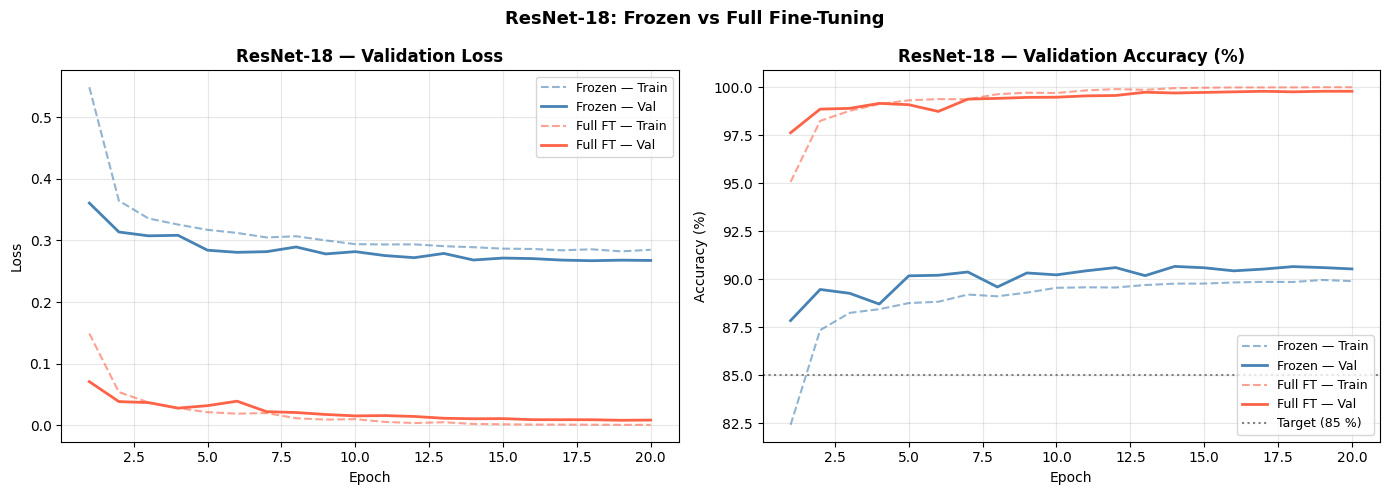

In [ ]:
# Training curves comparison
epochs_rn = range(1, RN_EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, key, title in zip(axes, ['loss', 'acc'], ['Loss', 'Accuracy (%)']):
    frozen_vals = [v * (100 if key == 'acc' else 1) for v in hist_frozen[f'val_{key}']]
    full_vals   = [v * (100 if key == 'acc' else 1) for v in hist_full[f'val_{key}']]
    train_frozen = [v * (100 if key == 'acc' else 1) for v in hist_frozen[f'train_{key}']]
    train_full   = [v * (100 if key == 'acc' else 1) for v in hist_full[f'train_{key}']]

    ax.plot(epochs_rn, train_frozen, '--', color='steelblue', alpha=0.6, label='Frozen — Train')
    ax.plot(epochs_rn, frozen_vals,       color='steelblue', linewidth=2, label='Frozen — Val')
    ax.plot(epochs_rn, train_full,  '--', color='tomato',    alpha=0.6, label='Full FT — Train')
    ax.plot(epochs_rn, full_vals,         color='tomato',    linewidth=2, label='Full FT — Val')

    if key == 'acc':
        ax.axhline(85, color='grey', linestyle=':', label='Target (85 %)')

    ax.set_title(f"ResNet-18: Validation {title}", fontsize=12, fontweight='bold')
    ax.set_xlabel("Epoch")
    ax.set_ylabel(title)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle("ResNet-18: Frozen vs Full Fine-Tuning", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('resnet_curves.png', dpi=120, bbox_inches='tight')
plt.show()


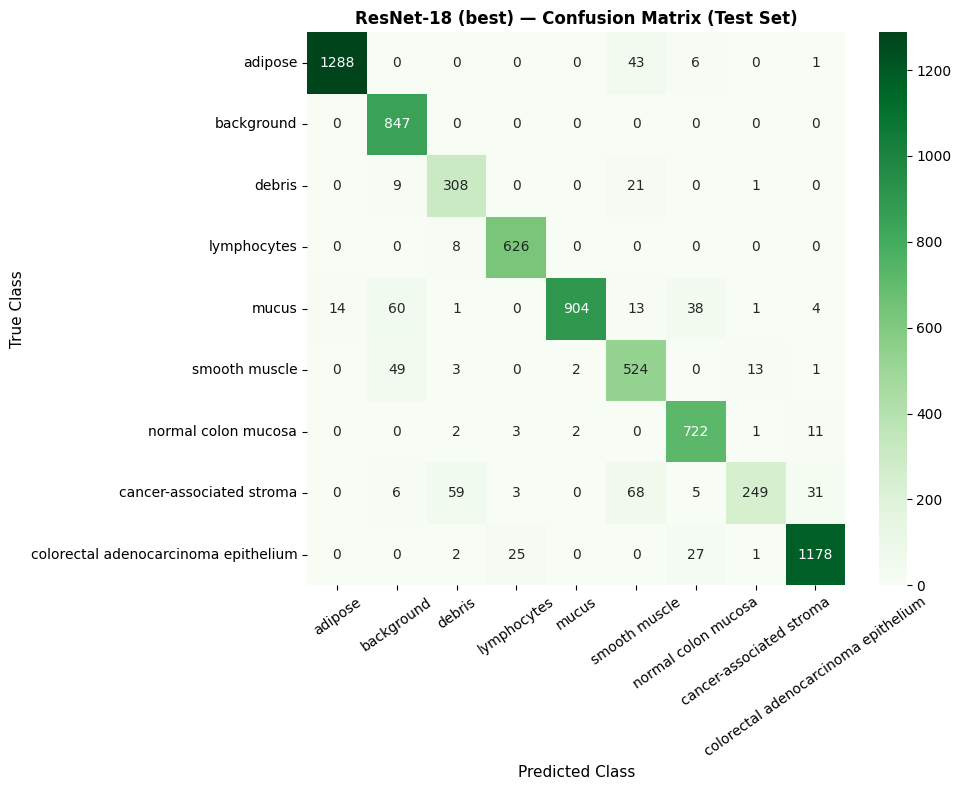


Per-class F1 scores (best ResNet-18):
                                      precision    recall  f1-score   support

                             adipose       0.99      0.96      0.98      1338
                          background       0.87      1.00      0.93       847
                              debris       0.80      0.91      0.85       339
                         lymphocytes       0.95      0.99      0.97       634
                               mucus       1.00      0.87      0.93      1035
                       smooth muscle       0.78      0.89      0.83       592
                 normal colon mucosa       0.90      0.97      0.94       741
            cancer-associated stroma       0.94      0.59      0.72       421
colorectal adenocarcinoma epithelium       0.96      0.96      0.96      1233

                            accuracy                           0.93      7180
                           macro avg       0.91      0.90      0.90      7180
                       

In [ ]:
# Confusion matrix for the better model
best_rn = resnet_full if test_acc_full >= test_acc_frozen else resnet_frozen
preds_rn, labels_rn = get_all_preds(best_rn, rn_test_loader, DEVICE)
cm_rn = confusion_matrix(labels_rn, preds_rn)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm_rn, annot=True, fmt='d', cmap='Greens',
            xticklabels=CLASSES, yticklabels=CLASSES, ax=ax)
ax.set_title("ResNet-18 (best) Confusion Matrix (Test Set)", fontsize=12, fontweight='bold')
ax.set_xlabel("Predicted Class", fontsize=11)
ax.set_ylabel("True Class", fontsize=11)
ax.tick_params(axis='x', rotation=35)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.savefig('resnet_confusion.png', dpi=120, bbox_inches='tight')
plt.show()

print("\nPer-class F1 scores (best ResNet-18):")
print(classification_report(labels_rn, preds_rn, target_names=CLASSES))


### Q4.1: Frozen vs Full Fine-Tuning

(a) Frozen backbone  : 87.4791%
(b) Full fine-tuning : 92.5627%
Difference           : 5.0836 percentage points
Better experiment    : Full fine-tuning

ImageNet images are usefull at the begining but are not adapted to histology images.
When we let all the different weights ajust, the results can improve
However, both experiences give good results, >85%, meaning the ResNet features are sufficient to be usefull for our dataset


### Q4.2: Consequence of 8× Upscaling (28×28 to 224×224)

Bilinear interpolation of a 28×28 image to 224×224 effectively **blurs the image**. Each original pixel is stretched over an 8×8 area of the enlarged canvas.  The model therefore "sees" a heavily smoothed version of the original patch where sharp edges, nuclear boundaries, and fine chromatin texture are replaced by gradient ramps.  High-frequency discriminative features (mitotic figure morphology, gland lumen sharpness) are destroyed.


Alternative strategy: Instead of upscaling the *image*, one can modify the ResNet's first convolutional layer to accept 28×28 inputs directly.
This keeps the original resolution intact throughout the network, avoids interpolation artefacts, and forces the network to learn features at the native 28×28 scale.  This approach typically yields slightly better feature quality at the cost of requiring re-initialisation of the first layer weights.


### Q4.3: Why Does Transfer Learning Work Here?

The claim that "ImageNet contains medical images" is **incorrect**.  ImageNet (ILSVRC) is a natural-image dataset containing everyday objects, dogs, cars, furniture, no histopathology slides.

The real reason transfer learning works is **feature hierarchy generalisation**:

- **Early layers** (conv1–conv2) of a pretrained ResNet learn low-level detectors: Gabor-like edge filters, colour blobs, and oriented gradients.  These features are genuinely domain-agnostic, edges and colour gradients exist in histology images just as they do in photographs.
- **Middle layers** (conv3–conv4) learn mid-level textures: grids, repeated patterns, surface textures.  Tissue microstructure (glandular patterns, cellular arrays) maps naturally onto these texture detectors.
- **Late layers** are more task-specific and benefit the most from fine-tuning on the target domain.

Because the low- and mid-level feature detectors are transferable, the network starts with a useful initialisation rather than random weights, requiring fewer epochs and less data to converge.  This is especially valuable for medical datasets where labelled data is scarce.


---
## Part 6: Grad-CAM Interpretability

**Grad-CAM** (Gradient-weighted Class Activation Mapping) visualises which regions of an image the model focused on to make its prediction. We implement it from scratch using PyTorch hooks.

Answer the question : which pixels influenced the model decision ?

**Algorithm:**
1. Forward pass : capture activations of the last conv layer
2. Backward pass : capture gradients flowing into that layer
3. Weight each activation map by the mean gradient of its channel : `[C, 1, 1] × [C, H, W]`
4. Sum across channels : `[H, W]`
5. Apply ReLU : keep only positive contributions
6. Normalise to [0, 1] and overlay as a heatmap on the original image


In [ ]:
# Grad-CAM
import torch.nn.functional as F
import matplotlib.cm as cm

class GradCAM:
    def __init__(self, model, target_layer):
        self.model        = model
        self.target_layer = target_layer
        self.activations  = None
        # saved by forward hook, what layer has detected
        self.gradients    = None
        # saved by backward hook, how each activation contributed to prediction
        self._register_hooks()

    def _register_hooks(self):
        # Forward hook: runs AFTER the layer computes its output
        # Saves the activation maps (what the layer detected)
        def forward_hook(module, input, output):
            self.activations = output.detach()
            # get values

        # Backward hook: runs AFTER backprop passes through this layer
        # Saves the gradients (how important each activation was)
        def backward_hook(module, grad_input, grad_output):
            self.gradients = grad_output[0].detach()

        self.target_layer.register_forward_hook(forward_hook)
        self.target_layer.register_full_backward_hook(backward_hook)

    def __call__(self, input_tensor, cls=None):
        self.model.eval()

        # Step 1 Forward pass (also triggers forward_hook)
        # Put the image in the network
        # Hook saves activation of the layer
        logits = self.model(input_tensor)
        if cls is None:
            cls = logits.argmax(dim=1).item()

        # Step 2 Backward pass for the chosen class (triggers backward_hook)
        self.model.zero_grad()
        logits[0, cls].backward()
        # Compute the gradient for the class of interest
        # Not the global loss
        # Meaning : how each parameter contributed to the score

        # Step 3 Global average pooling of gradients, one weight per channel
        # gradients shape: [1, C, h, w]
        # weights shape: [1, C, 1, 1]  (mean over spatial dims h, w)
        weights = self.gradients.mean(dim=[2, 3], keepdim=True)

        # Weighted sum of activation maps
        cam = (weights * self.activations).sum(dim=1, keepdim=True)

        # Step 4 ReLU: only keep regions that positively contributed
        # We keep only areas which increased the class scoring
        cam = F.relu(cam)

        # Step 5 Normalisation to [0, 1]
        cam = cam.squeeze()
        cam = cam - cam.min()
        if cam.max() > 0:
            cam = cam / cam.max()
        # Avoid division by 0
        return cam.cpu().numpy(), cls


In [ ]:
# Helper functions

def overlay_heatmap(img_tensor, cam, alpha=0.45):
    # Superpose Grad-CAM heatmap onto the original image

    H, W = img_tensor.shape[1], img_tensor.shape[2]

    # Resize image size using bilinear interpolation
    cam_t = torch.tensor(cam).unsqueeze(0).unsqueeze(0)
    cam_r = F.interpolate(cam_t, size=(H, W), mode='bilinear',
                          align_corners=False).squeeze().numpy()

    # Bring image back to displayable [0,1] range
    img_np = img_tensor.permute(1, 2, 0).cpu().numpy()
    img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min() + 1e-8)

    # Convert to RGB using jet colormap (blue=low, red=high attention)
    heatmap = cm.jet(cam_r)[:, :, :3]

    # Alpha blend
    blended = (1 - alpha) * img_np + alpha * heatmap
    return np.clip(blended, 0, 1), cam_r


def find_example(dataset, class_idx, model, device, correct=True):
    # Find a correct and incorrect image
    model.eval()
    for img, label in dataset:
        lbl = int(label)
        if lbl != class_idx:
            continue
        with torch.no_grad():
            pred = model(img.unsqueeze(0).to(device)).argmax(1).item()
        if correct and pred == lbl:
            return img, lbl, pred
        if not correct and pred != lbl:
            return img, lbl, pred
    return None, None, None


def find_any_wrong(dataset, model, device):
    # Returns the first misclassified image found in dataset
    # For question 6.2
    model.eval()
    for img, label in dataset:
        lbl = int(label)
        with torch.no_grad():
            pred = model(img.unsqueeze(0).to(device)).argmax(1).item()
        if pred != lbl:
            return img, lbl, pred
    return None, None, None


In [ ]:
# Attach Grad-CAM to ResNet-18
# We hook into layer4[1].conv2 : the very last convolutional layer.
# Early layers detect low-level features (edges, colours)
# Late layers detect high-level semantic features (tissue patterns)
# The last conv layer gives the most interpretable spatial heatmap
# It combines both spatial resolution and semantic meaning

target_layer = resnet_full.layer4[1].conv2
gcam = GradCAM(model=resnet_full, target_layer=target_layer)

print("Grad-CAM ready.")
print("Target layer : resnet_full.layer4[1].conv2")
print("Output shape of this layer : [1, 512, 7, 7] for 224×224 inputs")
print("(7×7 heatmap will be upscaled to 224×224 for overlay)")


Grad-CAM ready.
Target layer : resnet_full.layer4[1].conv2
Output shape of this layer : [1, 512, 7, 7] for 224×224 inputs
(7×7 heatmap will be upscaled to 224×224 for overlay)


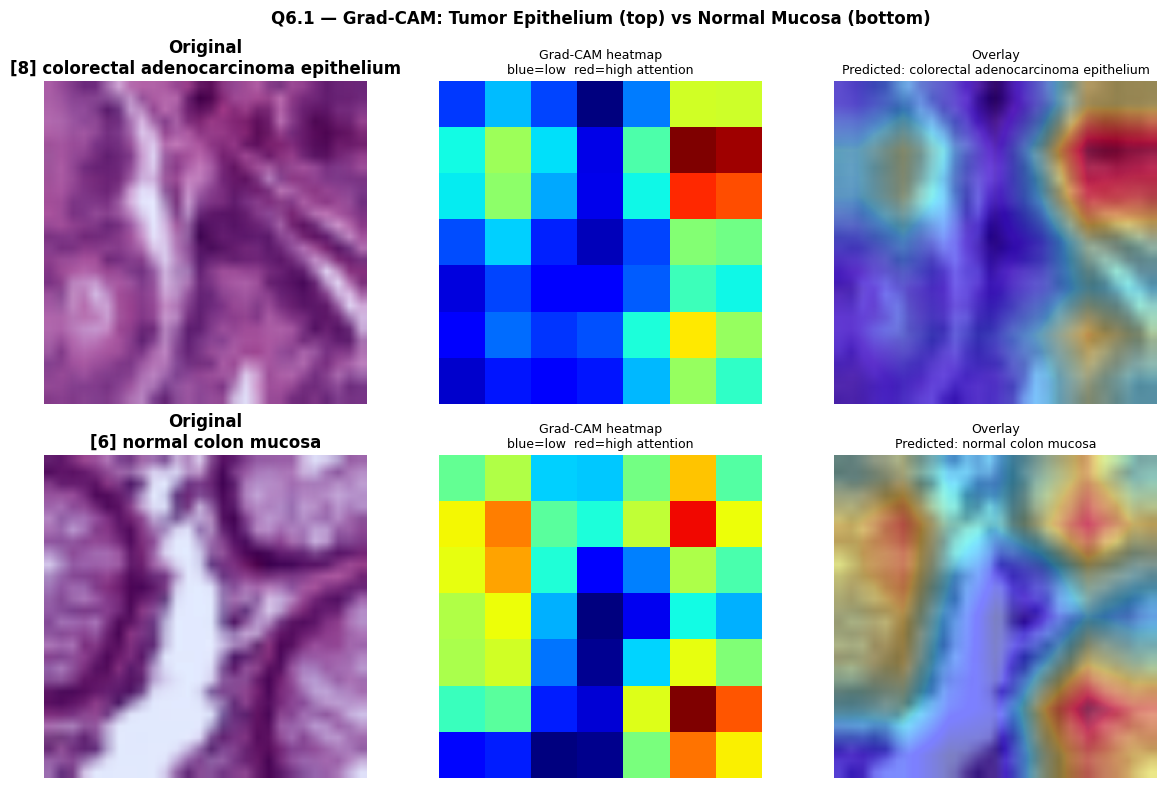

In [ ]:
# Q6.1 Tumor Epithelium vs Normal Mucosa
TUMOR    = 8   # Tumor Epithelium
MUCOSA   = 6   # Normal Mucosa

img_t, lbl_t, pred_t = find_example(test_rn, TUMOR,  resnet_full, DEVICE, correct=True)
img_m, lbl_m, pred_m = find_example(test_rn, MUCOSA, resnet_full, DEVICE, correct=True)

cam_t, _ = gcam(img_t.unsqueeze(0).to(DEVICE), cls=TUMOR)
cam_m, _ = gcam(img_m.unsqueeze(0).to(DEVICE), cls=MUCOSA)

ov_t, _ = overlay_heatmap(img_t, cam_t)
ov_m, _ = overlay_heatmap(img_m, cam_m)

fig, axes = plt.subplots(2, 3, figsize=(12, 8))

for row, (img, cam, ov, lbl, pred, cls_idx) in enumerate([
        (img_t, cam_t, ov_t, lbl_t, pred_t, TUMOR),
        (img_m, cam_m, ov_m, lbl_m, pred_m, MUCOSA)]):

    # original image
    disp = img.permute(1,2,0).numpy()
    disp = (disp - disp.min()) / (disp.max() - disp.min() + 1e-8)
    axes[row,0].imshow(disp)
    axes[row,0].set_title(f"Original\n[{cls_idx}] {CLASSES[cls_idx]}", fontweight='bold')
    axes[row,0].axis('off')

    # raw heatmap
    axes[row,1].imshow(cam, cmap='jet', vmin=0, vmax=1)
    axes[row,1].set_title("Grad-CAM heatmap\nblue=low  red=high attention", fontsize=9)
    axes[row,1].axis('off')

    # overlay
    axes[row,2].imshow(ov)
    axes[row,2].set_title(f"Overlay\nPredicted: {CLASSES[pred]}", fontsize=9)
    axes[row,2].axis('off')

plt.suptitle("Q6.1 — Grad-CAM: Tumor Epithelium (top) vs Normal Mucosa (bottom)",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('gradcam_q6_1.png', dpi=120, bbox_inches='tight')
plt.show()


### Q6.1: Heatmap Differences Between Tumor Epithelium and Normal Mucosa

**Tumor Epithelium** : activation concentrated in the top right of the image. Localised and specific. Area with dense cell population. Rest of the image is blue: model ignores it

**Normal Mucosa** : heatmap is very different. Activation is dispersed in a few distinct zones. Ignore le lumen (inside of the colon).

**Key difference in one sentence:** Activation is localisated on the tumor vs peripheric activation in the healthy tissue. Model learned biological features to distinguish both classes


Misclassified image found:
  True class      : 8  (colorectal adenocarcinoma epithelium)
  Predicted class : 3  (lymphocytes)


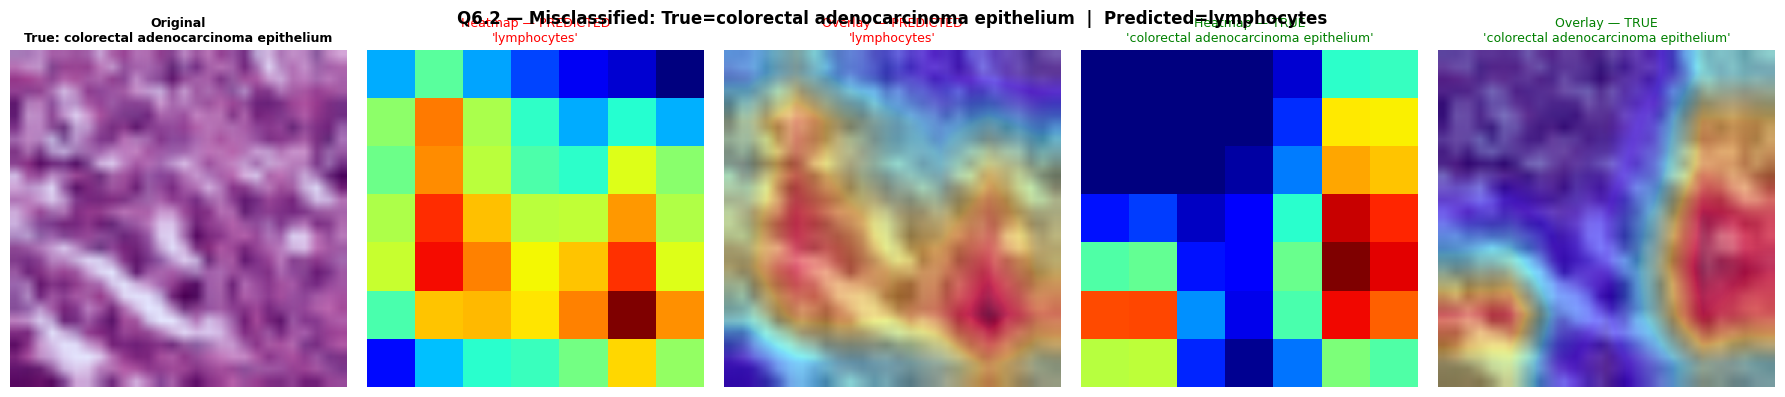

In [ ]:
# Q6.2: Misclassified image: heatmap for both classes
img_w, true_cls, pred_cls = find_any_wrong(test_rn, resnet_full, DEVICE)

print(f"Misclassified image found:")
print(f"  True class      : {true_cls}  ({CLASSES[true_cls]})")
print(f"  Predicted class : {pred_cls}  ({CLASSES[pred_cls]})")

# Heatmap explaining WHY the model chose the wrong class
cam_pred, _ = gcam(img_w.unsqueeze(0).to(DEVICE), cls=pred_cls)
# Heatmap showing what would have led to the correct class
cam_true, _ = gcam(img_w.unsqueeze(0).to(DEVICE), cls=true_cls)

ov_pred, _ = overlay_heatmap(img_w, cam_pred)
ov_true, _ = overlay_heatmap(img_w, cam_true)

disp = img_w.permute(1,2,0).numpy()
disp = (disp - disp.min()) / (disp.max() - disp.min() + 1e-8)

fig, axes = plt.subplots(1, 5, figsize=(18, 4))

axes[0].imshow(disp)
axes[0].set_title(f"Original\nTrue: {CLASSES[true_cls]}", fontweight='bold', fontsize=9)
axes[0].axis('off')

axes[1].imshow(cam_pred, cmap='jet', vmin=0, vmax=1)
axes[1].set_title(f"Heatmap — PREDICTED\n'{CLASSES[pred_cls]}'", fontsize=9, color='red')
axes[1].axis('off')

axes[2].imshow(ov_pred)
axes[2].set_title(f"Overlay — PREDICTED\n'{CLASSES[pred_cls]}'", fontsize=9, color='red')
axes[2].axis('off')

axes[3].imshow(cam_true, cmap='jet', vmin=0, vmax=1)
axes[3].set_title(f"Heatmap — TRUE\n'{CLASSES[true_cls]}'", fontsize=9, color='green')
axes[3].axis('off')

axes[4].imshow(ov_true)
axes[4].set_title(f"Overlay — TRUE\n'{CLASSES[true_cls]}'", fontsize=9, color='green')
axes[4].axis('off')

plt.suptitle(f"Q6.2 Misclassified: True={CLASSES[true_cls]}, Predicted={CLASSES[pred_cls]}",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('gradcam_q6_2.png', dpi=120, bbox_inches='tight')
plt.show()


### Q6.2: What the Two Heatmaps Reveal About the Confusion
The explanation is biological :
Tumoral tissue is very ofter infiltrated by immune cells such as lymphocytes. These immune cells can fight or help the spread of the tumor depending on different biological parameters. In the picture, accumulation of lymphocytes cells or cancer cells have a very similar profile.
The model focus on the infiltrate instead of the tumor area.


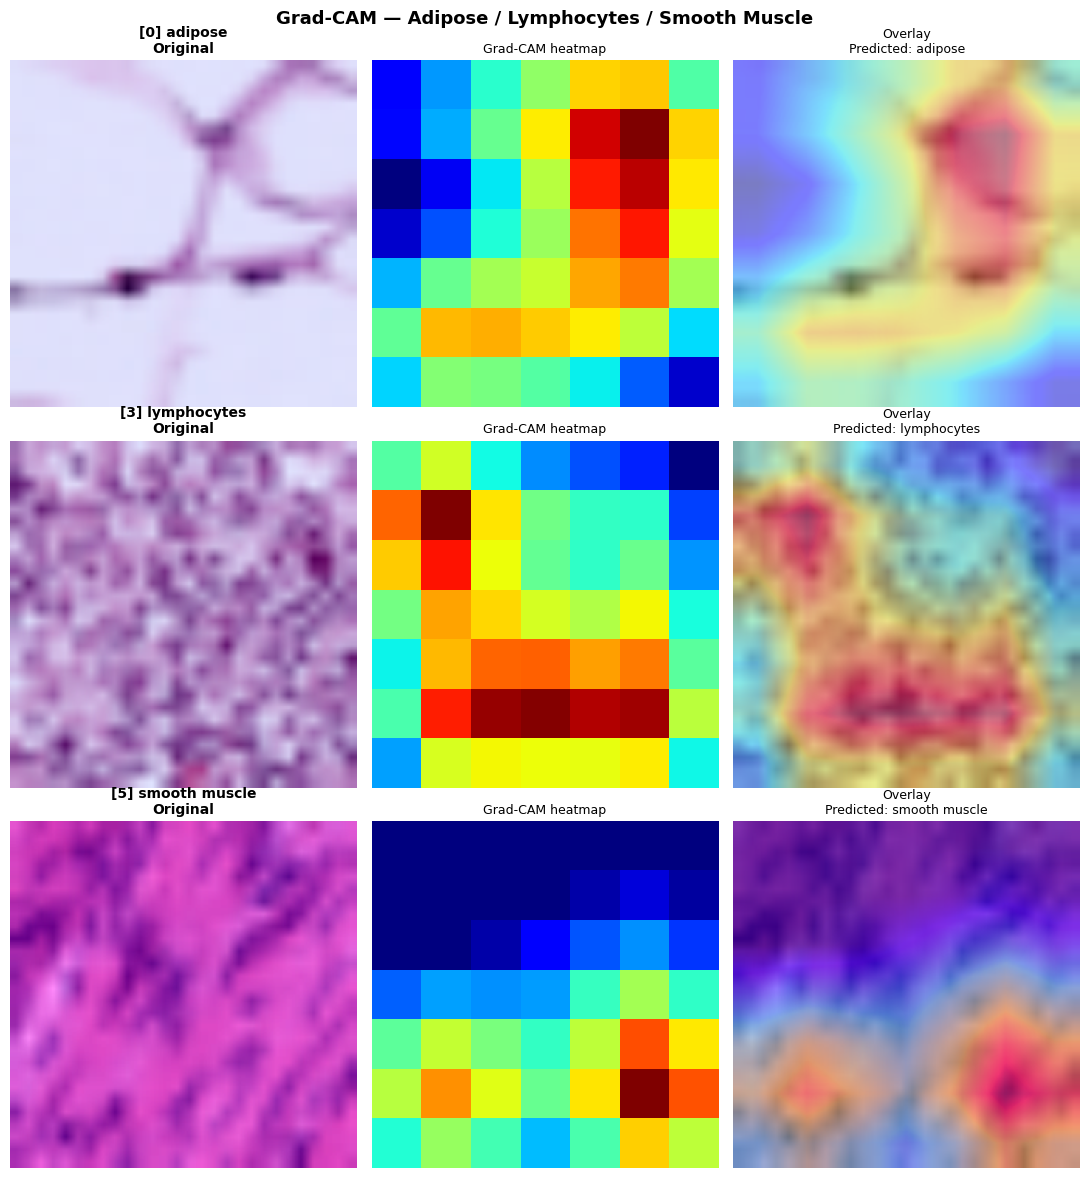

In [ ]:
# Grad-CAM for 3 more tissue types
SHOWCASE = [0, 3, 5]
# Adipose, Lymphocytes, Smooth Muscle

fig, axes = plt.subplots(len(SHOWCASE), 3, figsize=(11, 4 * len(SHOWCASE)))

for row, cls_idx in enumerate(SHOWCASE):
    img_s, lbl_s, pred_s = find_example(test_rn, cls_idx, resnet_full, DEVICE, correct=True)
    cam_s, _ = gcam(img_s.unsqueeze(0).to(DEVICE), cls=cls_idx)
    ov_s, _  = overlay_heatmap(img_s, cam_s)

    disp = img_s.permute(1,2,0).numpy()
    disp = (disp - disp.min()) / (disp.max() - disp.min() + 1e-8)

    axes[row,0].imshow(disp)
    axes[row,0].set_title(f"[{cls_idx}] {CLASSES[cls_idx]}\nOriginal",
                          fontweight='bold', fontsize=10)
    axes[row,0].axis('off')

    axes[row,1].imshow(cam_s, cmap='jet', vmin=0, vmax=1)
    axes[row,1].set_title("Grad-CAM heatmap", fontsize=9)
    axes[row,1].axis('off')

    axes[row,2].imshow(ov_s)
    axes[row,2].set_title(f"Overlay\nPredicted: {CLASSES[pred_s]}", fontsize=9)
    axes[row,2].axis('off')

plt.suptitle("Grad-CAM: Adipose / Lymphocytes / Smooth Muscle",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('gradcam_extra.png', dpi=120, bbox_inches='tight')
plt.show()
